# Water Use by County Data

This notebook reads in a .csv file of CONUS water use data at the county level.


*editing* </p>
processes CONUS-level USGS water use by county data. This notebook specifically subselects for ONLY Michigan county data from the CONUS dataset. County choice can be changed later in notebook.

In [1]:
import os
import geopandas as gpd
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import LinearSegmentedColormap

# Front Matter

## Inpaths

In [2]:
## path to county level water use data
dataPath = r'S:\Users\sigler\Data\Downloaded\USGS\CONUS\WaterUse'

## path for counties
countiesPath = r'S:\Projects\Active\WWAT\Data\GIS\Counties'

## Outpaths

In [3]:
outPath = r'S:\Users\sigler\Figures\WWAT'

# Read in Water Use data

In [4]:
## use the inPath to the county level water use data
inPath = os.path.join(dataPath, 'usco2015v2.0.csv')

In [5]:
## read in the county level water use data
df = pd.read_csv(inPath, encoding='latin1')

In [6]:
## make row 0 the header
df.columns = df.iloc[0]
df = df[1:]

In [7]:
df.head()

,STATE,STATEFIPS,COUNTY,COUNTYFIPS,FIPS,YEAR,TP-TotPop,PS-GWPop,PS-SWPop,PS-TOPop,...,TO-WGWTo,TO-WSWFr,TO-WSWSa,TO-WSWTo,TO-WFrTo,TO-WSaTo,TO-Wtotl,TO-CUsFrPartial,TO-CUsSaPartial,TO-CUTotPartial
1,AL,01,Autauga County,001,01001,2015,55.347,--,--,48.998,...,10.69,45.72,0.00,45.72,56.41,0.00,56.41,13.18,0.00,13.18
2,AL,01,Baldwin County,003,01003,2015,203.709,--,--,174.907,...,73.38,11.32,0.00,11.32,84.70,0.00,84.70,58.28,0.00,58.28
3,AL,01,Barbour County,005,01005,2015,26.489,--,--,24.587,...,6.06,2.96,0.00,2.96,9.02,0.00,9.02,2.96,0.00,2.96
4,AL,01,Bibb County,007,01007,2015,22.583,--,--,20.947,...,5.67,0.20,0.00,0.20,5.87,0.00,5.87,0.19,0.00,0.19
5,AL,01,Blount County,009,01009,2015,57.673,--,--,44.815,...,4.64,55.43,0.00,55.43,60.07,0.00,60.07,1.08,0.00,1.08


## Define State subselection

Currently selecting for Michigan counties

In [8]:
## create a new df made of the rows with 'MI' in the 'STATE' column
df = df[df['STATE'] == 'MI']

In [9]:
dfMI = df.copy()

In [10]:
dfMI.head()

,STATE,STATEFIPS,COUNTY,COUNTYFIPS,FIPS,YEAR,TP-TotPop,PS-GWPop,PS-SWPop,PS-TOPop,...,TO-WGWTo,TO-WSWFr,TO-WSWSa,TO-WSWTo,TO-WFrTo,TO-WSaTo,TO-Wtotl,TO-CUsFrPartial,TO-CUsSaPartial,TO-CUTotPartial
1232,MI,26,Alcona County,001,26001,2015,10.349,--,--,0.601,...,1.76,4.32,0.00,4.32,6.08,0.00,6.08,0.34,0.00,0.34
1233,MI,26,Alger County,003,26003,2015,9.383,--,--,4.399,...,1.11,3.64,0.00,3.64,4.75,0.00,4.75,0.03,0.00,0.03
1234,MI,26,Allegan County,005,26005,2015,114.625,--,--,33.117,...,22.29,8.63,0.00,8.63,30.92,0.00,30.92,13.23,0.00,13.23
1235,MI,26,Alpena County,007,26007,2015,28.803,--,--,15.795,...,1.11,119.75,0.00,119.75,120.86,0.00,120.86,0.10,0.00,0.10
1236,MI,26,Antrim County,009,26009,2015,23.154,--,--,9.194,...,11.27,29.08,0.00,29.08,40.32,0.03,40.35,8.19,0.00,8.19


# Merge datasets

## Read in county .shp

In [11]:
## use the county path to read in the counties shapefile
counties = gpd.read_file(os.path.join(countiesPath, 'Counties.shp'))

In [12]:
countiesMI = counties.copy()

In [13]:
countiesMI.head()

,OBJECTID,FIPSCODE,FIPSNUM,NAME,LABEL,TYPE,CNTY_CODE,SQKM,SQMILES,ACRES,VER,LAYOUT,PENINSULA,ShapeSTAre,ShapeSTLen,propCornA5,geometry
0,84,001,1,Alcona,Alcona County,County,001,1798.557,694.424,444428.381,14a,landscape,lower,3.559229e+09,242638.353149,0.007125,"POLYGON ((-83.88699 44.54081, -83.88701 44.542..."
1,85,003,3,Alger,Alger County,County,003,2424.879,936.247,599194.252,14a,landscape,upper,5.102846e+09,567351.604980,NaN,"MULTIPOLYGON (((-86.61526 46.28671, -86.61524 ..."
2,86,005,5,Allegan,Allegan County,County,005,2180.969,842.073,538923.422,14a,landscape,lower,4.028376e+09,261622.047738,0.156980,"POLYGON ((-85.54343 42.42905, -85.54344 42.428..."
3,87,007,7,Alpena,Alpena County,County,007,1539.373,594.352,380383.246,14a,landscape,lower,3.082999e+09,408567.836222,0.016957,"MULTIPOLYGON (((-83.3434 44.88554, -83.34308 4..."
4,88,009,9,Antrim,Antrim County,County,009,1358.721,524.603,335743.663,14a,landscape,lower,2.719403e+09,255626.802481,0.012450,"MULTIPOLYGON (((-84.84877 44.93222, -84.8487 4..."


## Perform merge

In [14]:
## merge the dfMI and counties MI dataframes
## in dfMI, use the 'COUNTY' column to match with the 'LABEL' column in countiesMI
countyWatUse = countiesMI.merge(dfMI, left_on='LABEL', right_on='COUNTY')


# Plotting

## Public GW withdrawls

In [15]:
countyWatUse['PS-WGWFr'] = pd.to_numeric(countyWatUse['PS-WGWFr'], errors='coerce')


In [16]:
countyWatUse['PS-WGWFr'].describe()

count    83.000000
mean      2.521807
std       4.665922
min       0.000000
25%       0.330000
50%       1.160000
75%       2.640000
max      26.090000
Name: PS-WGWFr, dtype: float64

In [17]:
# Truncate the 'pink' colormap to avoid the white end
def truncate_colormap(cmap, minval=0.0, maxval=0.85, n=100):
    return LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )

orig_cmap = plt.get_cmap('pink')
trunc_pink = truncate_colormap(orig_cmap, 0.0, 0.85)  # 0.85 avoids the white end

## reverse the colormap
trunc_pink_r = trunc_pink.reversed()

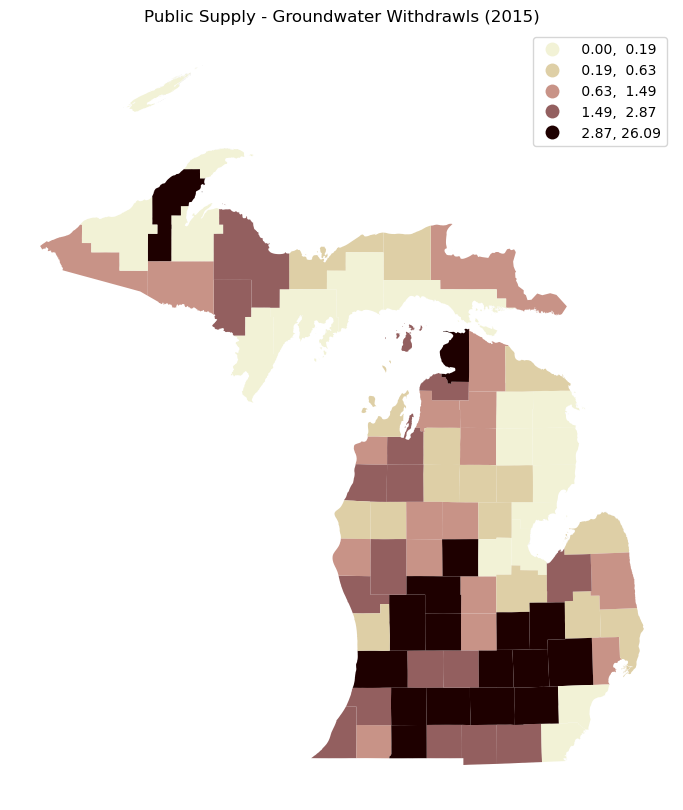

In [97]:
## plot county water use and color the counties by the 'TOTAL' column
#bins = [0.05, 0.33, 0.50, 1, 1.50, 2, 2.5, 3, 5, 10, 26.09]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
countyWatUse.plot(
    column='PS-WGWFr',
    ax=ax,
    legend=True,
    cmap=trunc_pink_r,
    scheme='quantiles',   # or 'equalinterval', 'fisherjenks', etc.
    # classification_kwds={'bins': bins}  # specify the bins for user-defined scheme
)
ax.set_axis_off()  # remove the axis
plt.title('Public Supply - Groundwater Withdrawls (2015)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [98]:
## save the figure to the outPath
fig.savefig(os.path.join(outPath, '2015publicGW.svg'), format='svg')

## Domestic GW withdrawls

In [18]:
countyWatUse['DO-WGWFr'] = pd.to_numeric(countyWatUse['DO-WGWFr'], errors='coerce')


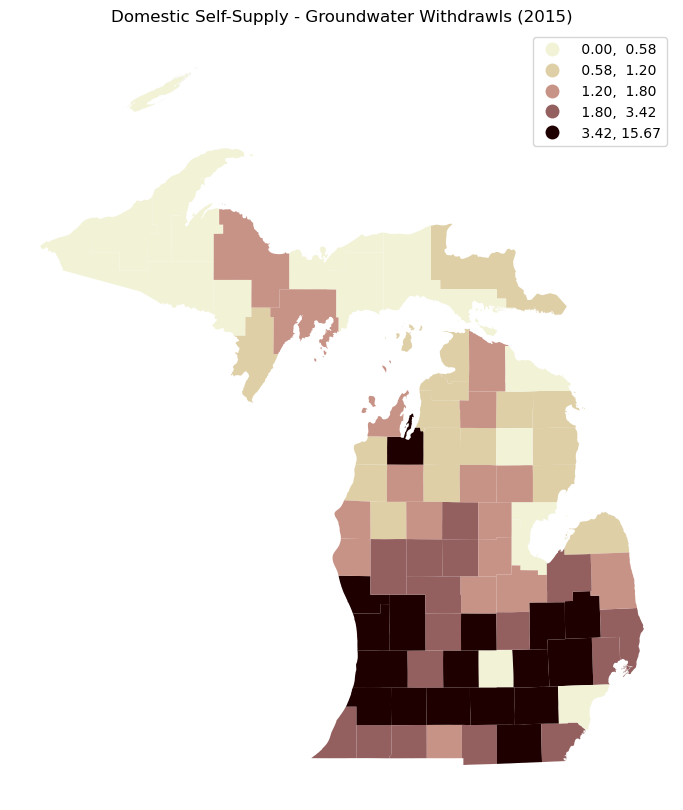

In [19]:
## plot county water use and color the counties by the 'TOTAL' column
bins = [0.04, 0.1, 0.5, 1, 1.50, 2, 2.5, 3, 5, 10, 26.09]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
countyWatUse.plot(
    column='DO-WGWFr',
    ax=ax,
    legend=True,
    cmap=trunc_pink_r,
    scheme='quantiles',   # or 'equalinterval', 'fisherjenks', etc.
)
ax.set_axis_off()  # remove the axis
plt.title('Domestic Self-Supply - Groundwater Withdrawls (2015)')
plt.show()

In [102]:
## save the figure to the outPath
fig.savefig(os.path.join(outPath, '2015domesticGW.svg'), format='svg')

# Make on same scale

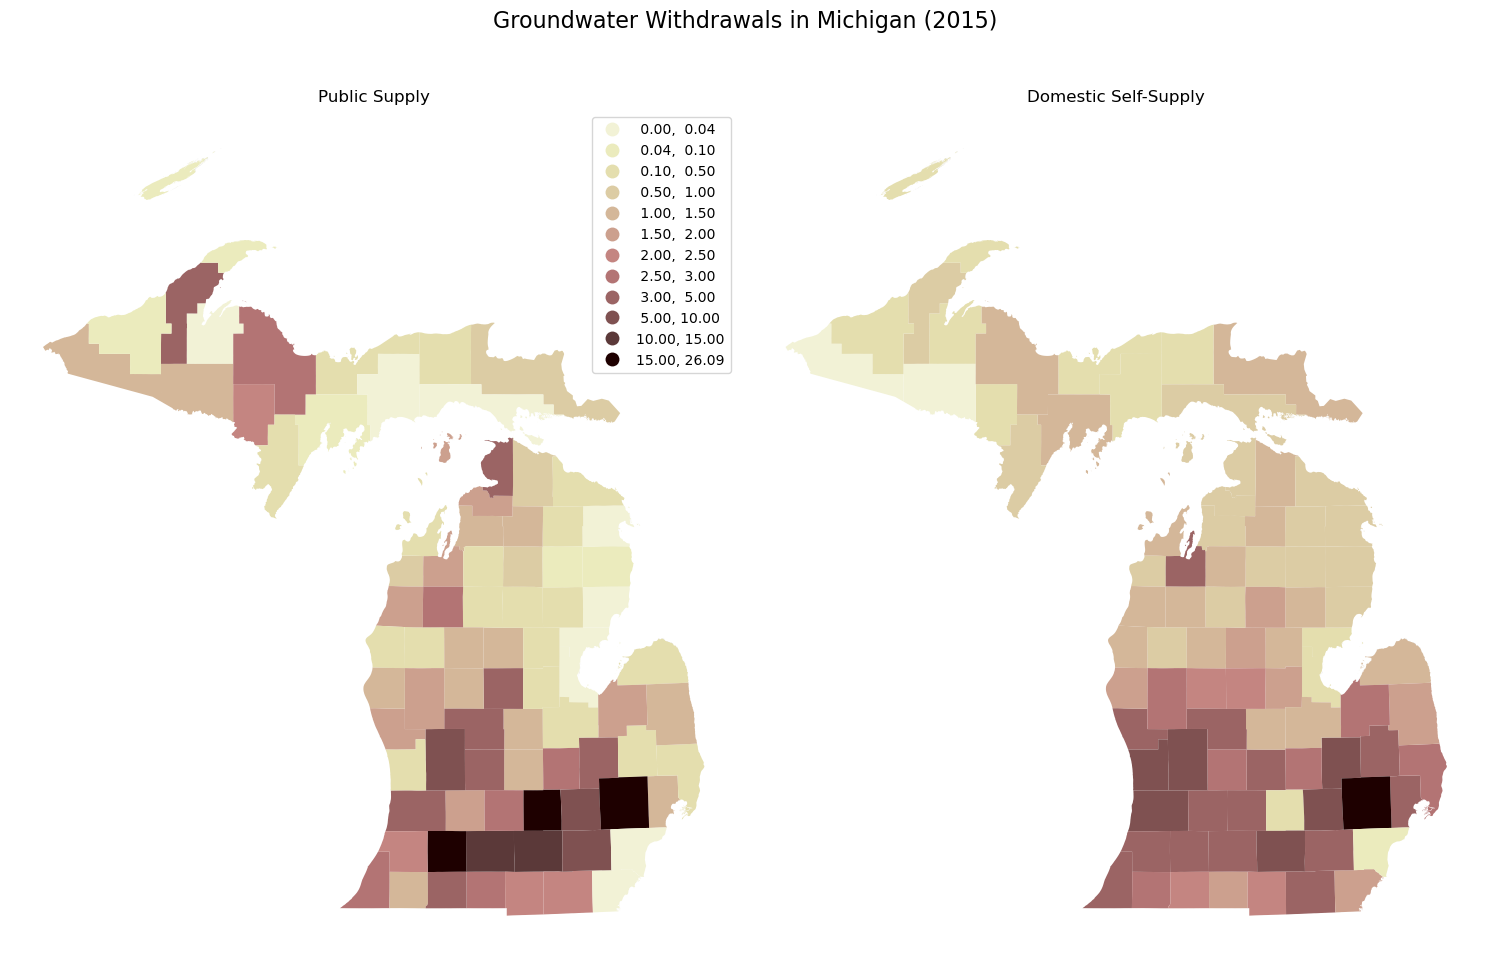

In [28]:
## set bins
bins = [0.04, 0.1, 0.5, 1, 1.5, 2, 2.5, 3, 5, 10, 15, 26.09]

## plot the countyWatUse.plot(column='PS-WGWFr') and countyWatUse.plot(column='DO-WGWFr') side by side
## and using the same color scale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))

# Plot Public Supply
countyWatUse.plot(
    column='PS-WGWFr',
    ax=ax1,
    legend=True,
    cmap=trunc_pink_r,
    scheme='user_defined',
    classification_kwds={'bins': bins}
)
ax1.set_title('Public Supply')

# Plot Domestic Self-Supply
countyWatUse.plot(
    column='DO-WGWFr',
    ax=ax2,
    legend=False,
    cmap=trunc_pink_r,
    scheme='user_defined',
    classification_kwds={'bins': bins}
)
ax2.set_title('Domestic Self-Supply')

# Turn off axis frames
ax1.set_axis_off()
ax2.set_axis_off()

plt.suptitle('Groundwater Withdrawals in Michigan (2015)', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [29]:
## save out fig as svg
fig.savefig(os.path.join(outPath, '2015GWcountyUse.svg'), format='svg')

## save out fig as png
